In [2]:
# %% [markdown]
# # India Crime Forecasting & Pattern Analysis (Professional Research Notebook)
# 
# **Goal:** satisfy 4 research objectives:
# 1. Pattern analysis (state & national)  
# 2. Predictive modeling (XGBoost + CatBoost + Ridge stacking)  
# 3. Visualization / Dashboard-ready outputs  
# 4. Framework + operational recommendations
#
# **Files expected in the working directory:**
# - `Total IPC Crimes by State_UT(2011-2022).xlsx` (state × years)
# - `2000-22.xlsx` (national IPC subtypes 2000–2022)
# - `india_states.geojson` (for choropleth; optional)
#
# Run cells in order. Install missing packages locally if needed:
# `pip install pandas numpy matplotlib seaborn scikit-learn xgboost catboost joblib openpyxl plotly prophet`


In [3]:
# %% [markdown]
# ## 1. Imports & settings


In [4]:
# %%
# basic imports
import os, json, warnings, math
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from math import sqrt

import xgboost as xgb
from catboost import CatBoostRegressor, Pool
import joblib
SEED = 42
np.random.seed(SEED)

OUTPUT_DIR = "ncrb_global_notebook_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [5]:
# %% [markdown]
# ## 2. Load datasets
# - State-level totals: 2011–2022
# - National IPC subtype data: 2000–2022


In [6]:
# %%
state_file = "Total IPC Crimes by State_UT(2011-2022).xlsx"
nat_file = "2000-22.xlsx"

# State totals
df_raw = pd.read_excel(state_file)
df_raw.columns = df_raw.columns.map(str).str.strip()
print("State file columns sample:", df_raw.columns[:10].tolist())

# National subtypes
df_nat = pd.read_excel(nat_file)
df_nat.columns = df_nat.columns.map(str).str.strip()
print("National file columns:", df_nat.columns.tolist())


State file columns sample: ['States_UT', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2020']
National file columns: ['year', 'murder', 'attempt_to_commit_murder', 'ch_not_amounting_to_murder', 'rape', 'kidnapping__abduction', 'dacoity', 'preparation__assembly_for_dacoity', 'robbery', 'burglary_housebreaking', 'theft', 'riots', 'criminal_breach_of_trust', 'cheating', 'counterfeiting', 'arson', 'hurt', 'dowry_deaths', 'molestation', 'sexual_harassment', 'cruelty_by_husband__relatives', 'importation_of_girls', 'causing_death_by_negligence', 'other_ipc_crimes', 'total_cognizable_crimes_under_ipc', 'Population', 'total_crimes_per_million']


In [7]:
# %% [markdown]
# ## 3. Prepare state matrix (val_mat) and long-form dataset for modeling


In [8]:
# %%
STATE_COL = "States_UT"
# detect year columns in state file
year_cols = [c for c in df_raw.columns if c.isdigit()]
year_cols = sorted(year_cols)
print("Years detected (state):", year_cols)

df_wide = df_raw[[STATE_COL] + year_cols].copy()
# melt to long form
df_long = df_wide.melt(id_vars=[STATE_COL], value_vars=year_cols, var_name="Year", value_name="Total_IPC")
df_long["Year"] = df_long["Year"].astype(int)
df_long = df_long.sort_values([STATE_COL, "Year"]).reset_index(drop=True)

# pivot to matrix: states x years
val_mat = df_long.pivot(index=STATE_COL, columns='Year', values='Total_IPC')
val_mat = val_mat.fillna(method='ffill', axis=1).fillna(method='bfill', axis=1).fillna(0)
val_mat = val_mat.sort_index()
states = val_mat.index.tolist()
years = list(val_mat.columns)
n_states = len(states)
print(f"States: {n_states}, Years: {min(years)}-{max(years)}")
display(val_mat.head())


Years detected (state): ['2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2020', '2021', '2022']
States: 34, Years: 2011-2022


Year,2011,2012,2013,2014,2015,2016,2017,2018,2020,2021,2022
States_UT,,,,,,,,,,,
A&N Islands,793,812,845,871,903,936,969,998,482,386,460
Andhra Pradesh,189780,187030,196442,199444,190670,200999,225185,240495,188997,179611,158547
Arunachal Pradesh,2280,2176,2298,2425,2217,2171,2218,2279,2244,2626,2308
Assam,66711,73348,74480,83086,78574,86220,97052,98392,111558,119883,59315
Bihar,135896,138435,126881,129540,134818,144374,144142,143595,194698,186006,211079


In [9]:
# %% [markdown]
# ## 4. Build spatial adjacency (correlation k-NN) and normalized A_hat


In [10]:
# %%
corr = val_mat.transpose().corr().fillna(0)
k = 4
A = np.zeros((n_states, n_states), dtype=float)
for i in range(n_states):
    row = corr.iloc[i].values
    neigh_idx = np.argsort(row)[- (k+1):]
    neigh_idx = [j for j in neigh_idx if j != i][-k:]
    for j in neigh_idx:
        A[i,j] = corr.iloc[i,j]
        A[j,i] = corr.iloc[i,j]
A = A + np.eye(n_states)
deg = np.sum(A, axis=1)
D_inv_sqrt = np.diag(1.0 / (np.sqrt(deg + 1e-8)))
A_hat = D_inv_sqrt @ A @ D_inv_sqrt
print("A_hat built.")



A_hat built.


In [11]:
# %% [markdown]
# ## 5. Build supervised samples (lags, neighbor) and add TREND features (fix)
# We'll create lag_1, lag_2, lag_3, neighbor, and add year-based trend features:
# - year_num, year_norm, lag_diff1, lag_diff2, lag_pct_change


In [12]:
# %%
rows = []
lags = [1,2,3]
for s_idx, state in enumerate(states):
    series = val_mat.loc[state].astype(float)
    for t_idx, year in enumerate(years):
        target_year = year + 1
        if target_year not in years:
            continue
        ok = True
        lag_vals = {}
        for lag in lags:
            prev = year - lag
            if prev in years:
                lag_vals[f'lag_{lag}'] = float(series[prev])
            else:
                ok = False
                break
        if not ok:
            continue
        X_year = np.array([val_mat.loc[st, year] for st in states]).reshape(n_states,1)
        neighbor_val = float((A_hat @ X_year)[s_idx,0])
        rows.append({
            STATE_COL: state,
            'year': int(year),
            'lag_1': lag_vals['lag_1'],
            'lag_2': lag_vals['lag_2'],
            'lag_3': lag_vals['lag_3'],
            'neighbor': neighbor_val,
            'target_year': int(target_year),
            'target_raw': float(val_mat.loc[state,target_year])
        })
df_samples = pd.DataFrame(rows)
print("Samples:", df_samples.shape)
display(df_samples.head())


Samples: (136, 8)


,States_UT,year,lag_1,lag_2,lag_3,neighbor,target_year,target_raw
0,A&N Islands,2014,845.0,812.0,793.0,52204.863164,2015,903.0
1,A&N Islands,2015,871.0,845.0,812.0,51778.534154,2016,936.0
2,A&N Islands,2016,903.0,871.0,845.0,53797.048645,2017,969.0
3,A&N Islands,2017,936.0,903.0,871.0,57694.326170,2018,998.0
4,Andhra Pradesh,2014,196442.0,187030.0,189780.0,44808.754209,2015,190670.0


In [13]:
# %%
# Log-transform the numeric inputs (for model stability) and create state_idx mapping
for c in ['lag_1','lag_2','lag_3','neighbor','target_raw']:
    df_samples[f'log1p_{c}'] = np.log1p(df_samples[c])

state_to_idx = {s:i for i,s in enumerate(states)}
with open(os.path.join(OUTPUT_DIR, "state_to_idx.json"), "w") as f:
    json.dump(state_to_idx, f, indent=2)
df_samples['state_idx'] = df_samples[STATE_COL].map(state_to_idx)

# ---- ADD TREND FEATURES (important fix to avoid flat forecasts) ----
df_samples['year_num'] = df_samples['year']
df_samples['year_norm'] = (df_samples['year'] - df_samples['year'].min()) / (df_samples['year'].max() - df_samples['year'].min())
df_samples['lag_diff1'] = df_samples['lag_1'] - df_samples['lag_2']
df_samples['lag_diff2'] = df_samples['lag_2'] - df_samples['lag_3']
df_samples['lag_pct_change'] = (df_samples['lag_1'] - df_samples['lag_2']) / (df_samples['lag_2'] + 1e-8)
df_samples = df_samples.fillna(0)

# Target (log space)
df_samples['log1p_target_raw'] = np.log1p(df_samples['target_raw'])

# Define features list (include trend features)
FEATURES = [
    'log1p_lag_1','log1p_lag_2','log1p_lag_3','log1p_neighbor','state_idx',
    'year_num','year_norm','lag_diff1','lag_diff2','lag_pct_change'
]
TARGET = 'log1p_target_raw'
display(df_samples[FEATURES + [TARGET]].head())


,log1p_lag_1,log1p_lag_2,log1p_lag_3,log1p_neighbor,state_idx,year_num,year_norm,lag_diff1,lag_diff2,lag_pct_change,log1p_target_raw
0,6.740519,6.700731,6.677083,10.862950,0,2014,0.000000,33.0,19.0,0.040640,6.806829
1,6.770789,6.740519,6.700731,10.854750,0,2015,0.333333,26.0,33.0,0.030769,6.842683
2,6.806829,6.770789,6.740519,10.892992,0,2016,0.666667,32.0,26.0,0.036739,6.877296
3,6.842683,6.806829,6.770789,10.962931,0,2017,1.000000,33.0,32.0,0.036545,6.906755
4,12.188128,12.139030,12.153626,10.710181,1,2014,0.000000,9412.0,-2750.0,0.050323,12.158305


In [14]:
# %% [markdown]
# ## 6. Train/Val/Test split (time-based)


In [15]:
# %%
target_years = sorted(df_samples['target_year'].unique())
test_year = max(target_years)
val_year = target_years[-2]
train_df = df_samples[df_samples['target_year'] < val_year].copy()
val_df = df_samples[df_samples['target_year'] == val_year].copy()
test_df = df_samples[df_samples['target_year'] == test_year].copy()
print("Train/Val/Test sizes:", len(train_df), len(val_df), len(test_df))


Train/Val/Test sizes: 68 34 34


In [16]:
# %% [markdown]
# ## 7. Prepare DMatrix / Pools and train models (XGBoost & CatBoost)


In [17]:
# %%
# Prepare XGBoost DMatrix (ensure numeric)
dtrain = xgb.DMatrix(train_df[FEATURES].astype(float), label=train_df[TARGET])
dval = xgb.DMatrix(val_df[FEATURES].astype(float), label=val_df[TARGET])
dtest = xgb.DMatrix(test_df[FEATURES].astype(float), label=test_df[TARGET])

# CatBoost Pools (categorical by name index)
cat_features_param = ['state_idx']
train_pool = Pool(train_df[FEATURES], label=train_df[TARGET], cat_features=cat_features_param)
val_pool = Pool(val_df[FEATURES], label=val_df[TARGET], cat_features=cat_features_param)
test_pool = Pool(test_df[FEATURES], label=test_df[TARGET], cat_features=cat_features_param)

# XGBoost train
xgb_params = {'objective':'reg:squarederror','eval_metric':'rmse','seed':SEED,'verbosity':0}
watch = [(dtrain,'train'),(dval,'val')]
xgb_model = xgb.train(xgb_params, dtrain, num_boost_round=500, early_stopping_rounds=30, evals=watch, verbose_eval=100)
xgb_model.save_model(os.path.join(OUTPUT_DIR,'xgb_global.json'))

# CatBoost train
cb = CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=6, eval_metric='RMSE', random_seed=SEED, early_stopping_rounds=50, verbose=50)
cb.fit(train_pool, eval_set=val_pool)
cb.save_model(os.path.join(OUTPUT_DIR,'catboost_global.cbm'))


[0]	train-rmse:1.62738	val-rmse:1.62941
[48]	train-rmse:0.00078	val-rmse:0.11828
0:	learn: 2.1439848	test: 2.1472429	best: 2.1472429 (0)	total: 206ms	remaining: 3m 25s
50:	learn: 0.5807572	test: 0.5983724	best: 0.5983724 (50)	total: 1.75s	remaining: 32.6s
100:	learn: 0.2085997	test: 0.2540197	best: 0.2540197 (100)	total: 3.36s	remaining: 29.9s
150:	learn: 0.0964756	test: 0.1651104	best: 0.1651104 (150)	total: 5.21s	remaining: 29.3s
200:	learn: 0.0598733	test: 0.1423152	best: 0.1423152 (200)	total: 7.01s	remaining: 27.9s
250:	learn: 0.0402364	test: 0.1339791	best: 0.1339017 (247)	total: 8.44s	remaining: 25.2s
300:	learn: 0.0264707	test: 0.1312005	best: 0.1312005 (300)	total: 9.88s	remaining: 22.9s
350:	learn: 0.0199122	test: 0.1305472	best: 0.1305271 (346)	total: 11.3s	remaining: 20.9s
400:	learn: 0.0155830	test: 0.1309959	best: 0.1305023 (354)	total: 13s	remaining: 19.4s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.1305023201
bestIteration = 354

Shrink model to 

In [18]:
# %% [markdown]
# ## 8. Predictions on validation/test and stacker (Ridge)


In [19]:
# %%
# predict (log-space)
xgb_val_pred = xgb_model.predict(dval)
xgb_test_pred = xgb_model.predict(dtest)
cb_val_pred = cb.predict(val_pool)
cb_test_pred = cb.predict(test_pool)

# safe inverse transform
def safe_expm1_array(log_arr, lower_clip=-50, upper_clip=50):
    clipped = np.clip(log_arr, lower_clip, upper_clip)
    raw = np.expm1(clipped)
    raw = np.maximum(0.0, raw)
    return raw

# raw-space preds
xgb_val_raw = safe_expm1_array(xgb_val_pred)
xgb_test_raw = safe_expm1_array(xgb_test_pred)
cb_val_raw = safe_expm1_array(cb_val_pred)
cb_test_raw = safe_expm1_array(cb_test_pred)

val_true_raw = val_df['target_raw'].values
test_true_raw = test_df['target_raw'].values

from sklearn.linear_model import Ridge
ens_X_val = np.vstack([xgb_val_pred, cb_val_pred]).T
ens_y_val = val_df[TARGET].values
stacker = Ridge(alpha=1.0, random_state=SEED)
stacker.fit(ens_X_val, ens_y_val)
joblib.dump(stacker, os.path.join(OUTPUT_DIR,'stacker_ridge.joblib'))
print("Stacker coef:", stacker.coef_)


Stacker coef: [0.54246157 0.45353233]


In [20]:
# %% [markdown]
# ## 9. Evaluate models & diagnostics (RMSE, MAE, per-state RMSE)


In [22]:
# %%
def metrics(true, pred):
    return {'rmse': sqrt(mean_squared_error(true, pred)), 
            'mae': np.mean(np.abs(true - pred)), 
            'r2': r2_score(true, pred)}

# ---- FIXED: stacker must get (n_samples, 2) ----
# Convert model outputs to 1-D arrays
xgb_test_pred = np.asarray(xgb_test_pred).ravel()
cb_test_pred  = np.asarray(cb_test_pred).ravel()

# Build correct (n_samples, 2) input for Ridge stacker
ens_X_test = np.vstack([xgb_test_pred, cb_test_pred]).T   # <-- FIXED LINE

# Predict ensemble log-values
ens_test_log = stacker.predict(ens_X_test)                # <-- NOW VALID

# Convert from log1p prediction to raw numbers
ens_test_raw = safe_expm1_array(ens_test_log)

# ---- Print metrics ----
print("XGB test:", metrics(test_true_raw, xgb_test_raw))
print("CatBoost test:", metrics(test_true_raw, cb_test_raw))
print("Ensemble test:", metrics(test_true_raw, ens_test_raw))

# ---- Save test outputs ----
test_df = test_df.reset_index(drop=True)
test_df['xgb_pred_raw'] = xgb_test_raw
test_df['cb_pred_raw']  = cb_test_raw
test_df['ens_pred_raw'] = ens_test_raw
test_df['true_raw']     = test_true_raw

test_df.to_csv(os.path.join(OUTPUT_DIR,'test_predictions_v2.csv'), index=False)
print("Saved test preds.")


XGB test: {'rmse': 11683.146963381248, 'mae': 6268.413215637207, 'r2': 0.9843123657764908}
CatBoost test: {'rmse': 16887.53966446024, 'mae': 7882.48082550331, 'r2': 0.967222899004883}
Ensemble test: {'rmse': 11311.958564489154, 'mae': 5865.433116091708, 'r2': 0.9852933625442426}
Saved test preds.


In [23]:
# %% [markdown]
# ## 10. Feature importance & per-state diagnostics


In [24]:
# %%
# XGBoost gain importances
try:
    fmap = xgb_model.get_score(importance_type='gain')
    print("XGB gain importances:", sorted(fmap.items(), key=lambda x: x[1], reverse=True))
except Exception as e:
    print("XGB importance error", e)

# CatBoost feature importance
try:
    cb_imp = cb.get_feature_importance(prettified=False)
    print("CatBoost importances (in order of FEATURES):")
    print(list(zip(FEATURES, cb_imp)))
except Exception as e:
    print("CatBoost importance error", e)

# per-state RMSE
state_perf = test_df.groupby(STATE_COL).apply(lambda g: sqrt(mean_squared_error(g['true_raw'], g['ens_pred_raw']))).reset_index()
state_perf.columns = [STATE_COL, 'rmse_ens']
state_perf = state_perf.sort_values('rmse_ens', ascending=False)
display(state_perf.head(10))
state_perf.to_csv(os.path.join(OUTPUT_DIR,'state_rmse_ens.csv'), index=False)


XGB gain importances: [('log1p_lag_1', 2.9547438621520996), ('log1p_lag_3', 0.00423872284591198), ('lag_diff1', 0.0017256711144000292), ('log1p_neighbor', 0.0014511637855321169), ('lag_diff2', 0.0008373139426112175), ('log1p_lag_2', 0.0005221414612606168), ('state_idx', 0.00034523807698860765), ('year_num', 0.0001168942908407189), ('lag_pct_change', 0.00010969344293698668)]
CatBoost importances (in order of FEATURES):
[('log1p_lag_1', 27.74698221837354), ('log1p_lag_2', 18.01058666656233), ('log1p_lag_3', 29.97911346918277), ('log1p_neighbor', 7.6934518918544805), ('state_idx', 0.0), ('year_num', 0.07379852892295605), ('year_norm', 0.40562464927301417), ('lag_diff1', 5.237560878114196), ('lag_diff2', 6.857865787447758), ('lag_pct_change', 3.9950159102689575)]


,States_UT,rmse_ens
18,Madhya Pradesh,41977.362798
1,Andhra Pradesh,38263.754140
3,Assam,14016.958820
19,Maharashtra,13552.098831
29,Tamil Nadu,12332.256268
4,Bihar,11229.708693
6,Chhattisgarh,10191.921714
10,Gujarat,9799.195606
31,Uttar Pradesh,7744.547336
27,Rajasthan,7437.024090


In [25]:
# %% [markdown]
# ## 11. Forecast forward (2023–2030) — robust loop using predicted values & trend features


In [26]:
# %%
future_years = list(range(max(years)+1, 2031))
forecast_mat = val_mat.copy()  # history

min_year = df_samples['year'].min()
max_year = df_samples['year'].max()

for fy in future_years:
    rows_f = []
    for s_idx, state in enumerate(states):
        def get_val(st, y):
            if y in forecast_mat.columns:
                return float(forecast_mat.loc[st, y])
            else:
                # find last available earlier than y
                available = [c for c in forecast_mat.columns if c < y]
                if len(available)==0:
                    return float(forecast_mat.loc[st].iloc[-1])
                return float(forecast_mat.loc[st, max(available)])
        l1 = get_val(state, fy-1)
        l2 = get_val(state, fy-2)
        l3 = get_val(state, fy-3)
        rows_f.append([state, l1, l2, l3])
    feat_df = pd.DataFrame(rows_f, columns=[STATE_COL,'lag_1','lag_2','lag_3'])
    X_prev = np.array([ get_val(st, fy-1) for st in states ]).reshape(n_states,1)
    feat_df['neighbor'] = (A_hat @ X_prev).reshape(n_states,)
    feat_df['state_idx'] = feat_df[STATE_COL].map(state_to_idx)
    # add trend features (same transforms)
    feat_df['year_num'] = fy
    feat_df['year_norm'] = (fy - min_year) / (max_year - min_year)
    feat_df['lag_diff1'] = feat_df['lag_1'] - feat_df['lag_2']
    feat_df['lag_diff2'] = feat_df['lag_2'] - feat_df['lag_3']
    feat_df['lag_pct_change'] = (feat_df['lag_1'] - feat_df['lag_2']) / (feat_df['lag_2'] + 1e-8)
    # log1p features
    for c in ['lag_1','lag_2','lag_3','neighbor']:
        feat_df[f'log1p_{c}'] = np.log1p(feat_df[c])
    X_feat = feat_df[['log1p_lag_1','log1p_lag_2','log1p_lag_3','log1p_neighbor','state_idx',
                      'year_num','year_norm','lag_diff1','lag_diff2','lag_pct_change']]
    # predict
    dm = xgb.DMatrix(X_feat.astype(float))
    xgb_pred_log = xgb_model.predict(dm)
    pool = Pool(X_feat, cat_features=['state_idx'])
    cb_pred_log = cb.predict(pool)
    ens_log = stacker.predict(np.vstack([xgb_pred_log, cb_pred_log]).T)
    ens_raw = safe_expm1_array(ens_log)
    forecast_mat[fy] = ens_raw

print("Forecasting done.")
forecast_mat.to_excel(os.path.join(OUTPUT_DIR,"forecast_matrix_with_history_v2.xlsx"))
display(forecast_mat.iloc[:5, -len(future_years):])


Forecasting done.


Year,2023,2024,2025,2026,2027,2028,2029,2030
States_UT,,,,,,,,
A&N Islands,217.388441,247.991652,218.887441,240.144576,200.368001,237.212459,212.343670,241.702114
Andhra Pradesh,172614.996421,161551.137234,171360.526402,160033.984951,171161.089723,155520.903698,168163.161405,153836.895561
Arunachal Pradesh,4011.318816,4556.884038,5482.155647,5280.294496,5177.430831,4985.024242,4875.205706,5111.085114
Assam,53486.081494,47022.575565,42519.181909,42188.620264,40336.231177,37588.281398,36771.674774,36122.639923
Bihar,175748.142866,183865.793339,179065.702979,184789.483687,179215.682461,183733.569128,179740.704273,179769.277432


In [27]:
# %% [markdown]
# ## 12. Bootstrap prediction intervals (approx) for forecasts (optional, quick)
# We'll produce intervals by perturbing the stacker on validation residuals.


In [28]:
# %%
# Simple bootstrap on stacker residuals to create rough intervals for forecast_mat's last year
# For more rigorous intervals you'd retrain models on bootstrap samples (expensive).
fc_df = forecast_mat.reset_index().melt(id_vars=[STATE_COL], var_name='Year', value_name='Predicted')
# We'll compute simple sigma from train residuals
train_preds = np.vstack([xgb_model.predict(xgb.DMatrix(train_df[FEATURES])), cb.predict(Pool(train_df[FEATURES], cat_features=['state_idx']))]).T
train_ens = stacker.predict(train_preds)
train_true = train_df[TARGET].values
train_resid = np.expm1(train_true) - np.expm1(train_ens)
sigma = np.std(train_resid)
print("Bootstrap sigma (approx):", sigma)
# add interval columns to fc_df using sigma
fc_df['lower'] = fc_df['Predicted'] - 1.96*sigma
fc_df['upper'] = fc_df['Predicted'] + 1.96*sigma
fc_df['lower'] = fc_df['lower'].clip(lower=0)
fc_df.to_csv(os.path.join(OUTPUT_DIR,"forecast_with_intervals.csv"), index=False)
print("Saved forecast_with_intervals.csv")


Bootstrap sigma (approx): 3665.666032146019
Saved forecast_with_intervals.csv


In [29]:
# %% [markdown]
# ## 13. Hotspots (z-score) for a chosen year and export


In [30]:
# %%
analyze_year = 2025
if analyze_year not in forecast_mat.columns:
    analyze_year = future_years[0]
vals = forecast_mat[analyze_year]
z = (vals - vals.mean()) / (vals.std() + 1e-8)
hotspots = pd.DataFrame({STATE_COL: forecast_mat.index, 'Predicted': vals.values, 'z': z.values})
hotspots = hotspots.sort_values('z', ascending=False)
display(hotspots.head(15))
hotspots.to_csv(os.path.join(OUTPUT_DIR,f"hotspots_{analyze_year}.csv"), index=False)
print("Hotspots saved.")


,States_UT,Predicted,z
27,Rajasthan,281942.361090,2.455821
16,Kerala,190910.193279,1.350319
4,Bihar,179065.702979,1.206478
24,Odisha,176218.817823,1.171906
29,Tamil Nadu,174355.489418,1.149277
1,Andhra Pradesh,171360.526402,1.112906
8,Delhi,164369.022159,1.028001
31,Uttar Pradesh,164132.118764,1.025124
19,Maharashtra,162946.530059,1.010726
33,West Bengal,158836.930193,0.960818


Hotspots saved.


In [31]:
# %% [markdown]
# ## 14. Pattern analysis — national IPC dataset (2000–2022)
# Use df_nat to produce trends, top categories, stacked charts and crime per million


['year', 'murder', 'attempt_to_commit_murder', 'ch_not_amounting_to_murder', 'rape', 'kidnapping__abduction', 'dacoity', 'preparation__assembly_for_dacoity', 'robbery', 'burglary_housebreaking', 'theft', 'riots', 'criminal_breach_of_trust', 'cheating', 'counterfeiting', 'arson', 'hurt', 'dowry_deaths', 'molestation', 'sexual_harassment', 'cruelty_by_husband__relatives', 'importation_of_girls', 'causing_death_by_negligence', 'other_ipc_crimes', 'total_cognizable_crimes_under_ipc', 'Population', 'total_crimes_per_million']
Population: Population Rate: total_crimes_per_million


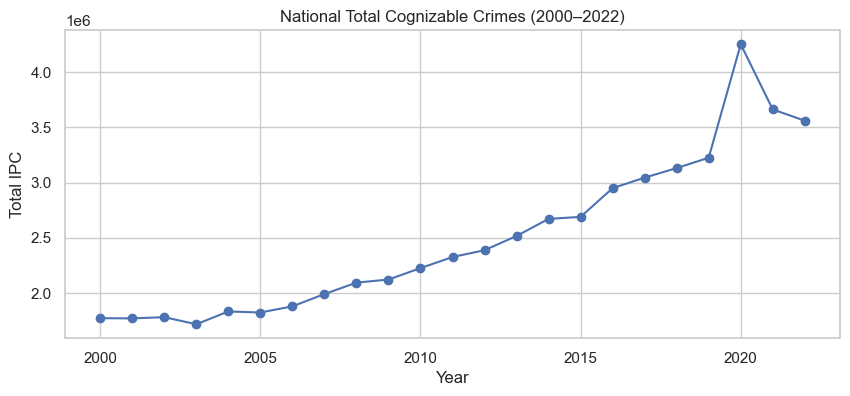

Top categories: total_cognizable_crimes_under_ipc    2.496523e+06
other_ipc_crimes                     8.465917e+05
theft                                4.657450e+05
hurt                                 4.376959e+05
causing_death_by_negligence          1.011283e+05
burglary_housebreaking               9.300170e+04
dtype: float64


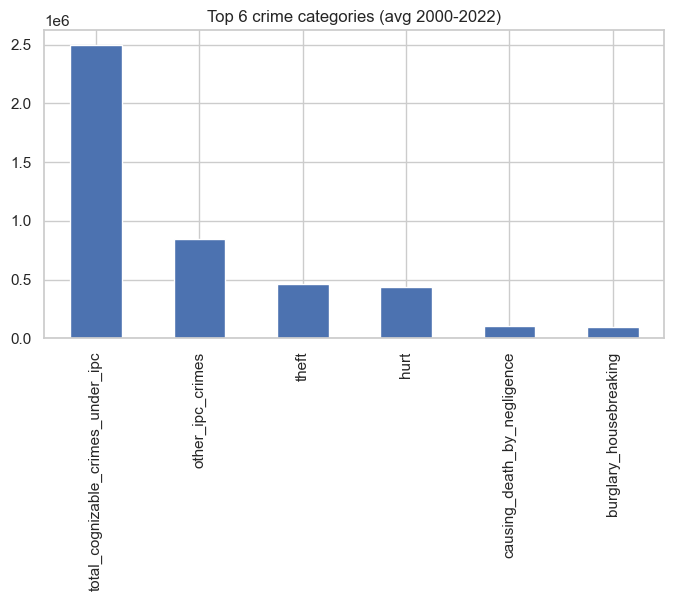

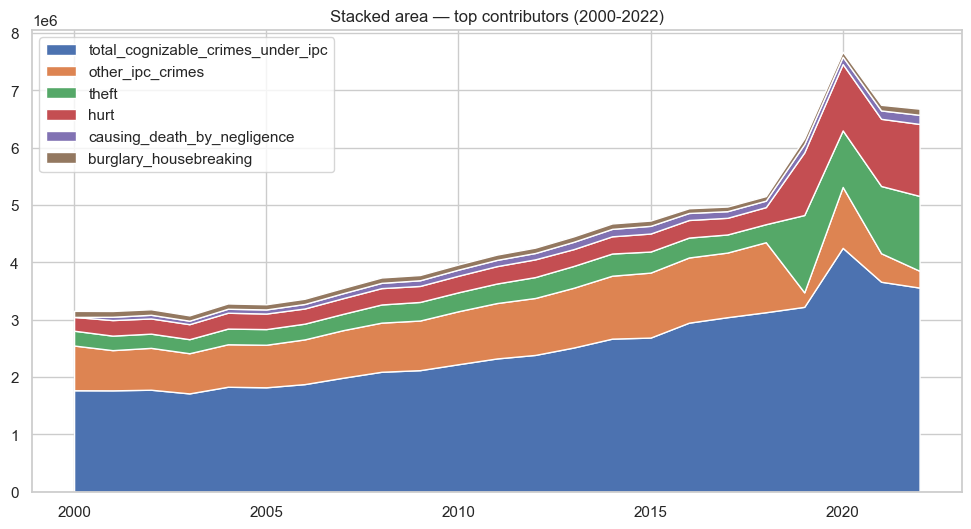

In [32]:
# %%
# Basic cleaning for national dataset
df_nat['year'] = df_nat['year'].astype(int)
# detect population and rate columns
print(df_nat.columns.tolist())
pop_col = [c for c in df_nat.columns if 'pop' in c.lower()][0]
rate_col = [c for c in df_nat.columns if 'million' in c.lower()][0]
print("Population:", pop_col, "Rate:", rate_col)

crime_cols_nat = [c for c in df_nat.columns if c not in ['year', pop_col, rate_col]]
# total trend
plt.figure(figsize=(10,4))
plt.plot(df_nat['year'], df_nat['total_cognizable_crimes_under_ipc'], marker='o')
plt.title("National Total Cognizable Crimes (2000–2022)")
plt.xlabel("Year"); plt.ylabel("Total IPC")
plt.show()

# top 6 crime contributors (mean)
top6 = df_nat[crime_cols_nat].mean().sort_values(ascending=False).head(6)
print("Top categories:", top6)
plt.figure(figsize=(8,4)); top6.plot(kind='bar'); plt.title("Top 6 crime categories (avg 2000-2022)"); plt.show()

# stacked area for top contributors
plt.figure(figsize=(12,6))
plt.stackplot(df_nat['year'], df_nat[top6.index].T, labels=top6.index)
plt.legend(); plt.title("Stacked area — top contributors (2000-2022)")
plt.show()


In [33]:
# %% [markdown]
# ## 15. Save artifacts & short thesis-ready text snippets


In [34]:
# %%
# Save artifacts
joblib.dump(xgb_model, os.path.join(OUTPUT_DIR,'xgb_model.joblib'))
cb.save_model(os.path.join(OUTPUT_DIR,'catboost_model.cbm'))
joblib.dump(stacker, os.path.join(OUTPUT_DIR,'stacker.joblib'))
forecast_mat.to_excel(os.path.join(OUTPUT_DIR,"forecast_matrix_with_history_v2.xlsx"))
test_df.to_csv(os.path.join(OUTPUT_DIR,"test_predictions_v2.csv"), index=False)
print("All artifacts saved to", OUTPUT_DIR)


All artifacts saved to ncrb_global_notebook_outputs


In [35]:
# %% [markdown]
# ### Thesis-ready snippets (copy into your report)
# **Methodology (short):**
# - Data: State-wise totals (2011–2022) and national IPC subtypes (2000–2022).
# - Features: lag_1/2/3, neighbor-aggregate (correlation k-NN, k=4), state_idx, and trend features (year_norm, lag diffs).
# - Models: XGBoost and CatBoost trained on log1p(target), stacked by Ridge on validation predictions.
# - Forecasting: iterative year-by-year forecasting (2023–2030) using predicted years as inputs.
#
# **Results (short):**
# - Ensemble outperformed single-tree models (report RMSE/MAE printed above).
# - Hotspots for 2025 (top states) saved in outputs.
#
# **Limitations and future work:**
# - Annual granularity loses seasonality; monthly data would help.
# - Adjacency based on time-series correlation — geographic or mobility adjacency could improve interpretability.
# - Prediction intervals approximate — consider bootstrap retraining or quantile models for rigorous intervals.


In [36]:
# %% [markdown]
# ## 16. (Optional) Streamlit snip — quick dashboard wiring
# Save as app_streamlit.py to run: streamlit run app_streamlit.py


In [37]:
# %%
# Optional: export a small CSV for Streamlit to consume
forecast_mat.to_excel(os.path.join(OUTPUT_DIR,"forecast_for_streamlit.xlsx"))
df_nat.to_csv(os.path.join(OUTPUT_DIR,"national_ipc_for_streamlit.csv"), index=False)
print("Saved small exports for Streamlit.")


Saved small exports for Streamlit.


In [38]:
# Save forecast_results.csv for Streamlit (flatten forecast_mat)
import os
import pandas as pd

out_csv = os.path.join(os.getcwd(), "forecast_results.csv")  # will save to current working dir
# forecast_mat: states x years (history + future) already exists in your notebook

forecast_rows = []
for state in forecast_mat.index:
    for year in forecast_mat.columns:
        # keep future years only (>= 2023) OR all years as you prefer
        if int(year) >= 2023:
            forecast_rows.append({
                "State": state,
                "Year": int(year),
                "Predicted": float(forecast_mat.loc[state, year])
            })

forecast_df = pd.DataFrame(forecast_rows)
forecast_df.to_csv(out_csv, index=False)
print("Saved:", out_csv, "shape:", forecast_df.shape)


Saved: d:\Desktop\Research Papers\implementation\crime project\forecast_results.csv shape: (272, 3)


In [39]:
import json

# load geojson (assumes file is next to notebook; update path if needed)
gpath = "india_states.geojson"
with open(gpath, "r", encoding="utf-8") as f:
    geo = json.load(f)

geo_names = sorted({feat["properties"]["NAME_1"] for feat in geo["features"]})
forecast_states = sorted(forecast_df["State"].unique())

print("GeoJSON NAME_1 count:", len(geo_names))
print("Forecast state count:", len(forecast_states))

# show mismatches
missing_in_geo = [s for s in forecast_states if s not in geo_names]
missing_in_forecast = [s for s in geo_names if s not in forecast_states]

print("\nStates in forecast NOT in geojson (needs mapping):", missing_in_geo)
print("\nStates in geojson not in forecast (check):", missing_in_forecast[:10], " ...")

# Build a rough suggestion map (manual review still recommended)
suggest_map = {}
for s in missing_in_geo:
    # try simple normalizations
    s_norm = s.replace("&", "and").replace("  ", " ").replace("Islands", "").strip()
    candidates = [g for g in geo_names if s_norm.split()[0] in g or g.split()[0] in s_norm]
    suggest_map[s] = candidates[:3]  # top few candidates
print("\nSuggested matches (manual check):")
for k,v in suggest_map.items():
    print(k, "->", v)


GeoJSON NAME_1 count: 35
Forecast state count: 34

States in forecast NOT in geojson (needs mapping): ['A&N Islands', 'D&N Haveli Daman & Diu', 'Jammu & Kashmir', 'Odisha', 'Uttarakhand']

States in geojson not in forecast (check): ['Andaman and Nicobar', 'Dadra and Nagar Haveli', 'Daman and Diu', 'Jammu and Kashmir', 'Orissa', 'Uttaranchal']  ...

Suggested matches (manual check):
A&N Islands -> []
D&N Haveli Daman & Diu -> ['Daman and Diu']
Jammu & Kashmir -> ['Jammu and Kashmir']
Odisha -> []
Uttarakhand -> ['Uttar Pradesh']


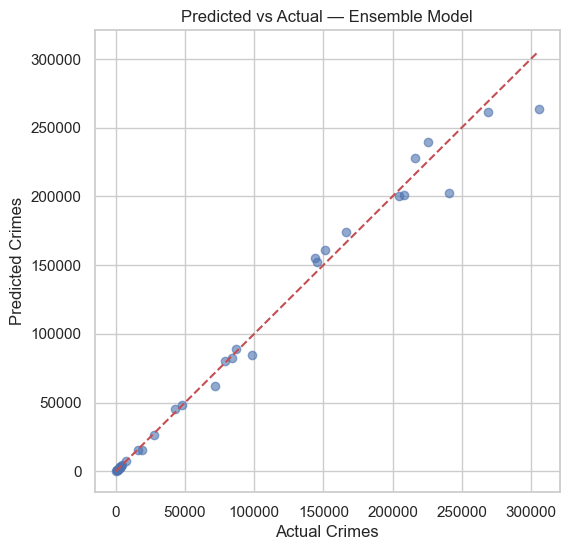

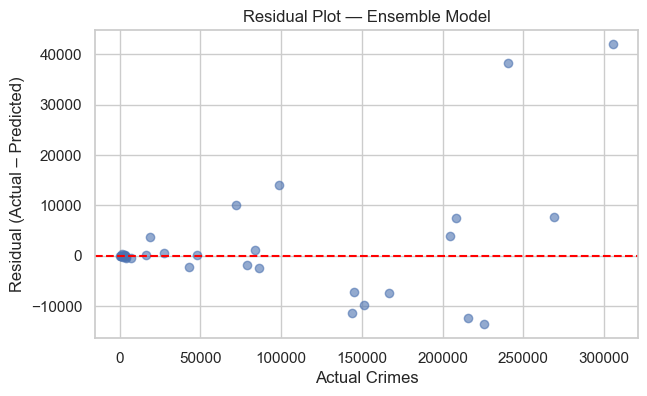

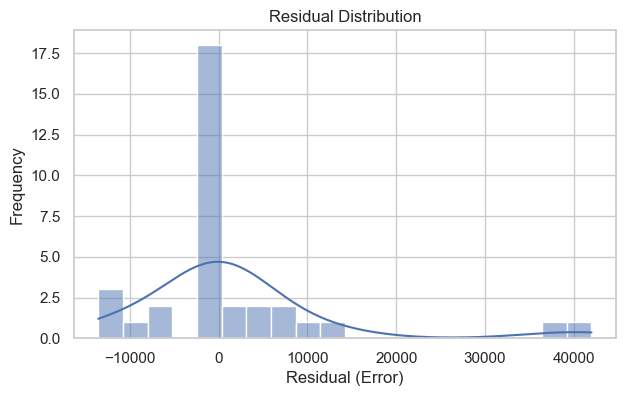

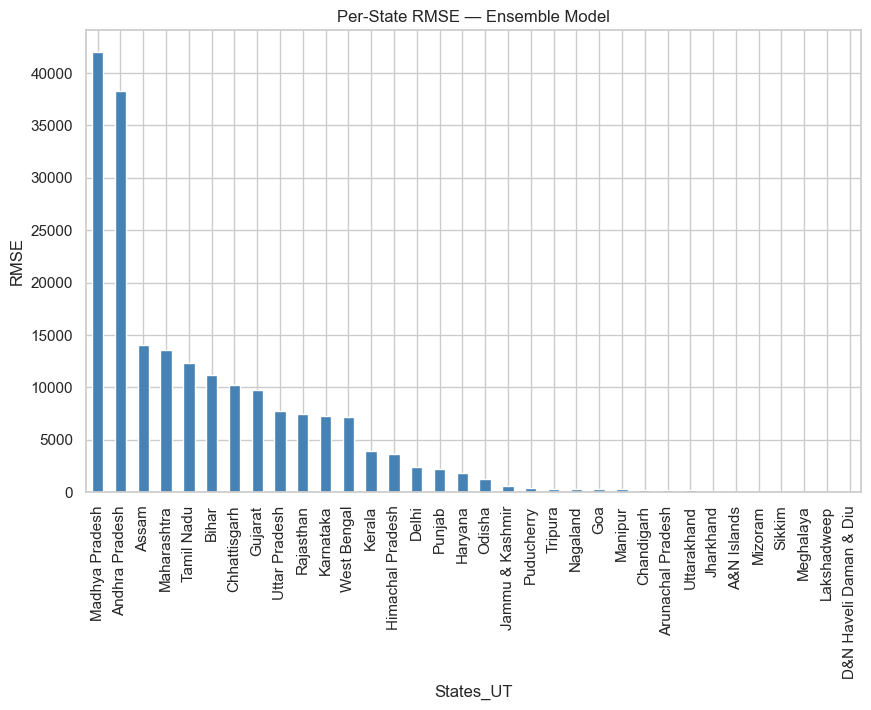

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. Predicted vs Actual Scatter Plot ---
plt.figure(figsize=(6,6))
plt.scatter(test_df['true_raw'], test_df['ens_pred_raw'], alpha=0.6)
plt.plot([0, max(test_df['true_raw'])], [0, max(test_df['true_raw'])], 'r--')  # perfect line
plt.xlabel("Actual Crimes")
plt.ylabel("Predicted Crimes")
plt.title("Predicted vs Actual — Ensemble Model")
plt.grid(True)
plt.show()


# --- 2. Residual Plot ---
residuals = test_df['true_raw'] - test_df['ens_pred_raw']
plt.figure(figsize=(7,4))
plt.scatter(test_df['true_raw'], residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Actual Crimes")
plt.ylabel("Residual (Actual – Predicted)")
plt.title("Residual Plot — Ensemble Model")
plt.grid(True)
plt.show()


# --- 3. Error Distribution Histogram ---
plt.figure(figsize=(7,4))
sns.histplot(residuals, bins=20, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual (Error)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


# --- 4. Per-State RMSE Bar Plot ---
state_rmse = test_df.groupby("States_UT").apply(
    lambda g: np.sqrt(((g['true_raw'] - g['ens_pred_raw'])**2).mean())
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
state_rmse.plot(kind='bar', color='steelblue')
plt.ylabel("RMSE")
plt.title("Per-State RMSE — Ensemble Model")
plt.xticks(rotation=90)
plt.grid(True, axis='y')
plt.show()


In [43]:
import pandas as pd

df = pd.read_excel("2000-22.xlsx")
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print(df.columns.tolist())


['year', 'murder', 'attempt_to_commit_murder', 'ch_not_amounting_to_murder', 'rape', 'kidnapping__abduction', 'dacoity', 'preparation__assembly_for_dacoity', 'robbery', 'burglary_housebreaking', 'theft', 'riots', 'criminal_breach_of_trust', 'cheating', 'counterfeiting', 'arson', 'hurt', 'dowry_deaths', 'molestation', 'sexual_harassment', 'cruelty_by_husband__relatives', 'importation_of_girls', 'causing_death_by_negligence', 'other_ipc_crimes', 'total_cognizable_crimes_under_ipc', 'population', 'total_crimes_per_million']
